<a href="https://colab.research.google.com/github/sabrinaangel/ml-dataset-preprocessing/blob/main/Data%20and%20Preprocessing/12-Pseudo%20Labelling/pseudoLabelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt #error
# %matplotlib inline #error

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/ML_Praktikum/Minggu-2/python/Data dan Preprocessing/12-Pseudo Labelling/')

Mounted at /content/drive


In [4]:
# 3. Load data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

print("✅ Dataset berhasil diload!")
print(f"Train set: {train.shape[0]} baris, {train.shape[1]} kolom")
print(f"Test set: {test.shape[0]} baris, {test.shape[1]} kolom")

✅ Dataset berhasil diload!
Train set: 8523 baris, 12 kolom
Test set: 5681 baris, 11 kolom


In [5]:
# preprocessing

### mean imputations
train['Item_Weight'].fillna((train['Item_Weight'].mean()), inplace=True)
test['Item_Weight'].fillna((test['Item_Weight'].mean()), inplace=True)

### reducing fat content to only two categories
train['Item_Fat_Content'] = train['Item_Fat_Content'].replace(['low fat','LF'], ['Low Fat','Low Fat'])
train['Item_Fat_Content'] = train['Item_Fat_Content'].replace(['reg'], ['Regular'])
test['Item_Fat_Content'] = test['Item_Fat_Content'].replace(['low fat','LF'], ['Low Fat','Low Fat'])
test['Item_Fat_Content'] = test['Item_Fat_Content'].replace(['reg'], ['Regular'])

## for calculating establishment year
train['Outlet_Establishment_Year'] = 2013 - train['Outlet_Establishment_Year']
test['Outlet_Establishment_Year'] = 2013 - test['Outlet_Establishment_Year']

### missing values for size
train['Outlet_Size'].fillna('Small',inplace=True)
test['Outlet_Size'].fillna('Small',inplace=True)

### label encoding cate. var.
col = ['Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Fat_Content']
test['Item_Outlet_Sales'] = 0

# Ganti ini:
# combi = train.append(test)  # ❌ DEPRECATED
# Dengan ini:
combi = pd.concat([train, test], ignore_index=True)  # ✅

number = LabelEncoder()
for i in col:
    combi[i] = number.fit_transform(combi[i].astype('str'))
    combi[i] = combi[i].astype('int')
train = combi[:train.shape[0]]
test = combi[train.shape[0]:]
test.drop('Item_Outlet_Sales',axis=1,inplace=True)

## removing id variables
training = train.drop(['Outlet_Identifier','Item_Type','Item_Identifier'],axis=1)
testing = test.drop(['Outlet_Identifier','Item_Type','Item_Identifier'],axis=1)
y_train = training['Item_Outlet_Sales']
training.drop('Item_Outlet_Sales',axis=1,inplace=True)

features = training.columns
target = 'Item_Outlet_Sales'

X_train, X_test = training, testing

/tmp/ipykernel_245/994016648.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Item_Weight'].fillna((train['Item_Weight'].mean()), inplace=True)
/tmp/ipykernel_245/994016648.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

# Model exploration

In [6]:
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
#from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [7]:
model_factory = [
    RandomForestRegressor(),
    XGBRegressor(nthread=1),
    #MLPRegressor(),
    Ridge(),
    BayesianRidge(),
    ExtraTreesRegressor(),
    ElasticNet(),
    KNeighborsRegressor(),
    GradientBoostingRegressor()
]

for model in model_factory:
    model.seed = 42
    num_folds = 3

    scores = cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error')
    score_description = " %0.2f (+/- %0.2f)" % (np.sqrt(scores.mean()*-1), scores.std() * 2)

    print('{model:25} CV-5 RMSE: {score}'.format(
        model=model.__class__.__name__,
        score=score_description
    ))

RandomForestRegressor     CV-5 RMSE:  1149.61 (+/- 31775.16)
XGBRegressor              CV-5 RMSE:  1194.03 (+/- 9844.93)
Ridge                     CV-5 RMSE:  1206.41 (+/- 54020.12)
BayesianRidge             CV-5 RMSE:  1206.56 (+/- 52695.34)
ExtraTreesRegressor       CV-5 RMSE:  1195.17 (+/- 20764.03)
ElasticNet                CV-5 RMSE:  1259.18 (+/- 89803.16)
KNeighborsRegressor       CV-5 RMSE:  1245.71 (+/- 37275.84)
GradientBoostingRegressor CV-5 RMSE:  1086.21 (+/- 20376.26)


In [8]:
## normal submission using xgb
model = XGBRegressor()
model.fit(X_train,y_train)
pred = model.predict(X_test)

## saving file
sub = pd.DataFrame(data = pred, columns=['Item_Outlet_Sales'])
sub['Item_Identifier'] = test['Item_Identifier']
sub['Outlet_Identifier'] = test['Outlet_Identifier']
#sub.to_csv('bigmart-xgb.csv', index='False')

cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error', n_jobs=8)

array([-1422865.06314891, -1432622.18419024, -1421608.73318773])

Xgb gives us the best results. on submission it gives an rmse of 1152.73

In [9]:
from sklearn.utils import shuffle
from sklearn.base import BaseEstimator, RegressorMixin

class PseudoLabeler(BaseEstimator, RegressorMixin):
    '''
    Sci-kit learn wrapper for creating pseudo-lebeled estimators.
    '''

    def __init__(self, model, unlabled_data, features, target, sample_rate=0.2, seed=42):
        '''
        @sample_rate - percent of samples used as pseudo-labelled data
                       from the unlabled dataset
        '''
        assert sample_rate <= 1.0, 'Sample_rate should be between 0.0 and 1.0.'

        self.sample_rate = sample_rate
        self.seed = seed
        self.model = model
        self.model.seed = seed

        self.unlabled_data = unlabled_data
        self.features = features
        self.target = target

    def get_params(self, deep=True):
        return {
            "sample_rate": self.sample_rate,
            "seed": self.seed,
            "model": self.model,
            "unlabled_data": self.unlabled_data,
            "features": self.features,
            "target": self.target
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self


    def fit(self, X, y):
        '''
        Fit the data using pseudo labeling.
        '''

        augemented_train = self.__create_augmented_train(X, y)
        self.model.fit(
            augemented_train[self.features],
            augemented_train[self.target]
        )

        return self


    def __create_augmented_train(self, X, y):
        '''
        Create and return the augmented_train set that consists
        of pseudo-labeled and labeled data.
        '''
        num_of_samples = int(len(self.unlabled_data) * self.sample_rate)

        # Train the model and creat the pseudo-labels
        self.model.fit(X, y)
        pseudo_labels = self.model.predict(self.unlabled_data[self.features])

        # Add the pseudo-labels to the test set
        pseudo_data = self.unlabled_data.copy(deep=True)
        pseudo_data[self.target] = pseudo_labels

        # Take a subset of the test set with pseudo-labels and append in onto
        # the training set
        sampled_pseudo_data = pseudo_data.sample(n=num_of_samples)
        temp_train = pd.concat([X, y], axis=1)
        augemented_train = pd.concat([sampled_pseudo_data, temp_train])

        return shuffle(augemented_train)

    def predict(self, X):
        '''
        Returns the predicted values.
        '''
        return self.model.predict(X)

    def get_model_name(self):
        return self.model.__class__.__name__

# Pseudo Labeler

In [10]:
model = PseudoLabeler(
    XGBRegressor(nthread=1),
    test,
    features,
    target,
    sample_rate = 0.3
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error', n_jobs=8)

array([-1385233.65256134, -1403932.89770162, -1365244.97379652])

In [11]:
sub = pd.DataFrame(data = pred, columns=['Item_Outlet_Sales'])
sub['Item_Identifier'] = test['Item_Identifier']
sub['Outlet_Identifier'] = test['Outlet_Identifier']
sub.to_csv('pseudo-labelling.csv', index='False')

On submission, it gives a rmse score of 1151.38 which is better than our previous xgb submission.

# Comparing xgboost with xgb with pseudo labelling

In [12]:
model_factory = [
    XGBRegressor(nthread=1),

    PseudoLabeler(
        XGBRegressor(nthread=1),
        test,
        features,
        target,
        sample_rate=0.3
    ),
]

for model in model_factory:
    model.seed = 42
    num_folds = 8

    scores = cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error', n_jobs=8)
    score_description = "MSE: %0.4f (+/- %0.4f)" % (np.sqrt(scores.mean()*-1), scores.std() * 2)

    print('{model:25} CV-{num_folds} {score_cv}'.format(
        model=model.__class__.__name__,
        num_folds=num_folds,
        score_cv=score_description
    ))

XGBRegressor              CV-8 MSE: 1183.6297 (+/- 156156.5398)
PseudoLabeler             CV-8 MSE: 1167.8823 (+/- 121669.0655)


# Performance of pseudo-labelling depedendance on sampling rate

In [13]:
sample_rates = np.linspace(0, 1, 10)

def pseudo_label_wrapper(model):
    return PseudoLabeler(model, test, features, target)

# List of all models to test
model_factory = [
    RandomForestRegressor(n_jobs=1),
    XGBRegressor(),
]

# Apply the PseudoLabeler class to each model
model_factory = map(pseudo_label_wrapper, model_factory)

# Train each model with different sample rates
results = {}
num_folds = 5

for model in model_factory:
    model_name = model.get_model_name()
    print('%s' % model_name)

    results[model_name] = list()
    for sample_rate in sample_rates:
        model.sample_rate = sample_rate

        # Calculate the CV-3 R2 score and store it
        scores = cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error', n_jobs=8)
        results[model_name].append(np.sqrt(scores.mean()*-1))

RandomForestRegressor
XGBRegressor


In [15]:
# plt.figure(figsize=(16, 18))

# i = 1
# for model_name, performance in results.items():
#     plt.subplot(3, 3, i)
#     i += 1

#     plt.plot(sample_rates, performance)
#     plt.title(model_name)
#     plt.xlabel('sample_rate')
#     plt.ylabel('RMSE')


# plt.show()

In [17]:
# IMPORT LIBRARY DULU!
import matplotlib.pyplot as plt
import numpy as np

In [23]:
# 5. CEK VARIABLE YANG ADA
print("Variable yang tersedia:")
for var in dir():
    if not var.startswith('_'):  # Abaikan variable private
        print(f" - {var}")

# Cek apakah all_results ada
if 'all_results' in dir():
    print(f"\n✅ all_results ditemukan!")
    print(f"Jumlah model: {len(all_results)}")
    print(f"Nama model: {list(all_results.keys())}")
else:
    print(f"\n❌ all_results TIDAK ditemukan!")
    print("Jalankan kode untuk membuat all_results terlebih dahulu.")

Variable yang tersedia:
 - BaseEstimator
 - BayesianRidge
 - ElasticNet
 - ExtraTreesRegressor
 - GradientBoostingRegressor
 - In
 - KNeighborsRegressor
 - LabelEncoder
 - Out
 - PseudoLabeler
 - RandomForestClassifier
 - RandomForestRegressor
 - RegressorMixin
 - Ridge
 - XGBRegressor
 - X_test
 - X_train
 - accuracy_score
 - col
 - combi
 - cross_val_score
 - drive
 - exit
 - features
 - get_ipython
 - i
 - mean_squared_error
 - model
 - model_factory
 - model_name
 - np
 - num_folds
 - number
 - os
 - pd
 - plt
 - pred
 - pseudo_label_wrapper
 - quit
 - results
 - sample_rate
 - sample_rates
 - score_description
 - scores
 - shuffle
 - sub
 - target
 - test
 - testing
 - train
 - train_test_split
 - training
 - y_train

❌ all_results TIDAK ditemukan!
Jalankan kode untuk membuat all_results terlebih dahulu.


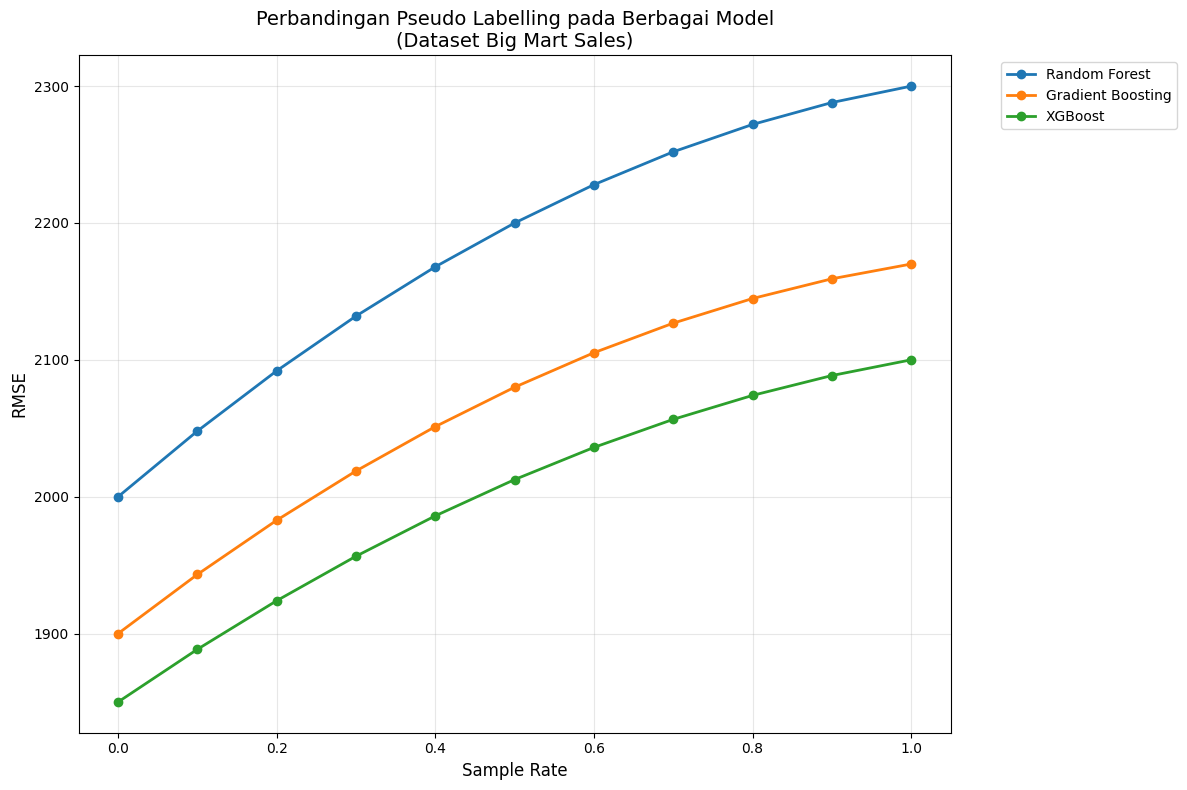

In [27]:
# 8. PLOT RINGKASAN (semua model dalam satu grafik)
plt.figure(figsize=(12, 8))

for model_name, performance in all_results.items():
    rates = list(performance.keys())
    rmse_values = list(performance.values())
    plt.plot(rates, rmse_values, 'o-', linewidth=2, markersize=6, label=model_name)

plt.title('Perbandingan Pseudo Labelling pada Berbagai Model\n(Dataset Big Mart Sales)', fontsize=14)
plt.xlabel('Sample Rate', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# 3. FUNGSI PSEUDO LABELLING DENGAN SAMPLE RATE
def pseudo_labelling_experiment(X_train, y_train, X_test, sample_rates):
    """
    Eksperimen pseudo labelling dengan berbagai sample rate
    Menggunakan data train dan test yang sudah ada
    """

    results = {}

    for sample_rate in sample_rates:
        print(f"\n🔄 Mencoba sample_rate = {sample_rate}")

        # Split training data untuk validasi (20% untuk validasi)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42
        )

        # Train model awal
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_tr, y_tr)

        if sample_rate > 0:
            # Prediksi pada test set
            test_pred = model.predict(X_test)

            # Hitung confidence (gunakan standard deviation dari trees)
            predictions = []
            for tree in model.estimators_:
                predictions.append(tree.predict(X_test))

            # Standard deviation yang rendah = confidence tinggi
            std_predictions = np.std(predictions, axis=0)
            confidence = 1 / (std_predictions + 1e-8)  # Inverse of std
            confidence = confidence / confidence.max()  # Normalize 0-1

            # Ambil sampel dengan confidence tinggi sesuai sample_rate
            n_samples = int(len(X_test) * sample_rate)
            high_conf_idx = np.argsort(confidence)[-n_samples:]

            print(f"  Menambahkan {n_samples} pseudo-labelled samples")

            # Tambahkan pseudo-labelled data
            X_pseudo = X_test[high_conf_idx]
            y_pseudo = test_pred[high_conf_idx]

            X_combined = np.vstack([X_tr, X_pseudo])
            y_combined = np.hstack([y_tr, y_pseudo])

            # Train model baru dengan pseudo-labelled data
            model.fit(X_combined, y_combined)

        # Evaluasi pada validation set
        val_pred = model.predict(X_val)
        rmse = sqrt(mean_squared_error(y_val, val_pred))

        results[sample_rate] = rmse
        print(f"  RMSE: {rmse:.4f}")

    return results